# Cane Corso Color Prediction — числов генетичен модел

Тестова проба за прогнозиране на възможни цветове при малки Cane Corso според гените на родителите.

Идеята е да дадем числова сила на гените.

За K locus приемаме:

- `KB = 3` → черен ген, най-силен
- `kbr = 2` → тигров ген
- `ky = 1` → fawn / рижав ген

Тоест:

`KB > kbr > ky`

След това добавяме D locus:

- `D/D` = нормален цвят
- `D/d` = нормален цвят, но носи dilute ген
- `d/d` = разреден цвят

Пример:

- черен + `d/d` = сив / blue
- тигров + `d/d` = сиво-тигров / blue brindle
- fawn + `d/d` = разреден fawn

Целта е да получим вероятности за цветовете на малките и да ги покажем с графика.


Всички възможни генетични комбинации:


,K генотип,K числова сила,K вероятност %,D генотип,D числова сила,D вероятност %,Комбинирана вероятност %,Основен цвят,Предвиден цвят
0,KB/ky,3,50.0,D/D,2,25.0,12.5,черен,черен
1,KB/ky,3,50.0,D/d,1,50.0,25.0,черен,черен
2,KB/ky,3,50.0,d/d,0,25.0,12.5,черен,сив / blue
3,ky/ky,1,50.0,D/D,2,25.0,12.5,fawn / рижав,fawn / рижав
4,ky/ky,1,50.0,D/d,1,50.0,25.0,fawn / рижав,fawn / рижав
5,ky/ky,1,50.0,d/d,0,25.0,12.5,fawn / рижав,разреден fawn


Вероятности за цветове:


,Цвят,Вероятност %
0,черен,37.5
2,fawn / рижав,37.5
1,сив / blue,12.5
3,разреден fawn,12.5


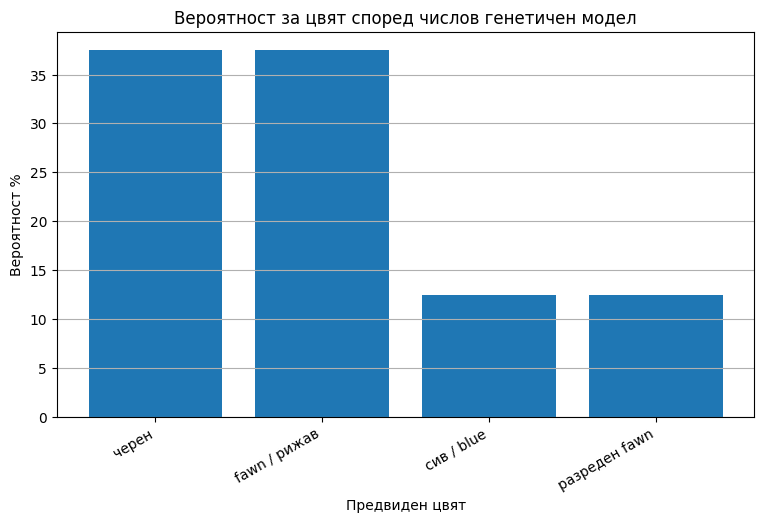

Обща вероятност: 100.0 %


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from IPython.display import display

# ======================================================
# 1. Родители
# ======================================================

father = {
    "име": "Баща",
    "K": ["KB", "ky"],   # черен, но носи fawn
    "D": ["D", "d"]      # носи dilute
}

mother = {
    "име": "Майка",
    "K": ["ky", "ky"],   # fawn / рижав
    "D": ["D", "d"]      # носи dilute
}

# ======================================================
# 2. Числова сила на гените
# ======================================================

K_GENE_SCORE = {
    "KB": 3,    # черен - най-силен
    "kbr": 2,   # тигров
    "ky": 1     # fawn / рижав
}

D_GENE_SCORE = {
    "D": 1,
    "d": 0
}

# ======================================================
# 3. Функции за вероятности
# ======================================================

def allele_probabilities(alleles):
    counts = Counter(alleles)
    total = len(alleles)
    
    return {
        allele: count / total
        for allele, count in counts.items()
    }


def genotype_probabilities(father_alleles, mother_alleles, score_map):
    father_probs = allele_probabilities(father_alleles)
    mother_probs = allele_probabilities(mother_alleles)
    
    result = defaultdict(float)
    
    for father_allele, father_probability in father_probs.items():
        for mother_allele, mother_probability in mother_probs.items():
            
            genotype = tuple(sorted(
                [father_allele, mother_allele],
                key=lambda gene: score_map[gene],
                reverse=True
            ))
            
            probability = father_probability * mother_probability
            result[genotype] += probability
    
    return dict(result)

# ======================================================
# 4. Функции за цвят
# ======================================================

def k_numeric_score(k_genotype):
    return max(K_GENE_SCORE[gene] for gene in k_genotype)


def d_numeric_score(d_genotype):
    return sum(D_GENE_SCORE[gene] for gene in d_genotype)


def base_color_from_k_score(k_score):
    if k_score == 3:
        return "черен"
    elif k_score == 2:
        return "тигров"
    else:
        return "fawn / рижав"


def final_color_from_scores(k_score, d_score):
    base_color = base_color_from_k_score(k_score)
    
    # d_score = 0 означава d/d, тоест разреден цвят
    if d_score == 0:
        if base_color == "черен":
            return "сив / blue"
        elif base_color == "тигров":
            return "сиво-тигров / blue brindle"
        else:
            return "разреден fawn"
    
    return base_color

# ======================================================
# 5. Изчисляване на възможните комбинации
# ======================================================

k_probs = genotype_probabilities(father["K"], mother["K"], K_GENE_SCORE)
d_probs = genotype_probabilities(father["D"], mother["D"], D_GENE_SCORE)

rows = []
color_probs = defaultdict(float)

for k_genotype, k_probability in k_probs.items():
    for d_genotype, d_probability in d_probs.items():
        
        combined_probability = k_probability * d_probability
        
        k_score = k_numeric_score(k_genotype)
        d_score = d_numeric_score(d_genotype)
        
        base_color = base_color_from_k_score(k_score)
        final_color = final_color_from_scores(k_score, d_score)
        
        color_probs[final_color] += combined_probability
        
        rows.append({
            "K генотип": "/".join(k_genotype),
            "K числова сила": k_score,
            "K вероятност %": k_probability * 100,
            
            "D генотип": "/".join(d_genotype),
            "D числова сила": d_score,
            "D вероятност %": d_probability * 100,
            
            "Комбинирана вероятност %": combined_probability * 100,
            "Основен цвят": base_color,
            "Предвиден цвят": final_color
        })

genotype_table = pd.DataFrame(rows)

color_table = pd.DataFrame({
    "Цвят": list(color_probs.keys()),
    "Вероятност %": [value * 100 for value in color_probs.values()]
})

color_table = color_table.sort_values("Вероятност %", ascending=False)

# ======================================================
# 6. Показване на резултатите
# ======================================================

print("Всички възможни генетични комбинации:")
display(genotype_table)

print("Вероятности за цветове:")
display(color_table)

# ======================================================
# 7. Графика
# ======================================================

plt.figure(figsize=(9, 5))
plt.bar(color_table["Цвят"], color_table["Вероятност %"])

plt.title("Вероятност за цвят според числов генетичен модел")
plt.xlabel("Предвиден цвят")
plt.ylabel("Вероятност %")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.show()

print("Обща вероятност:", round(color_table["Вероятност %"].sum(), 2), "%")

In [4]:
assert len(genotype_table) > 0
assert round(color_table["Вероятност %"].sum(), 2) == 100.00

print("Tests passed")

Tests passed


Пример 1: Черен носител x Fawn носител
Баща: {'K': ['KB', 'ky'], 'D': ['D', 'd']}
Майка: {'K': ['ky', 'ky'], 'D': ['D', 'd']}



,Цвят,Вероятност %
0,черен,37.5
2,fawn / рижав,37.5
1,сив / blue,12.5
3,разреден fawn,12.5


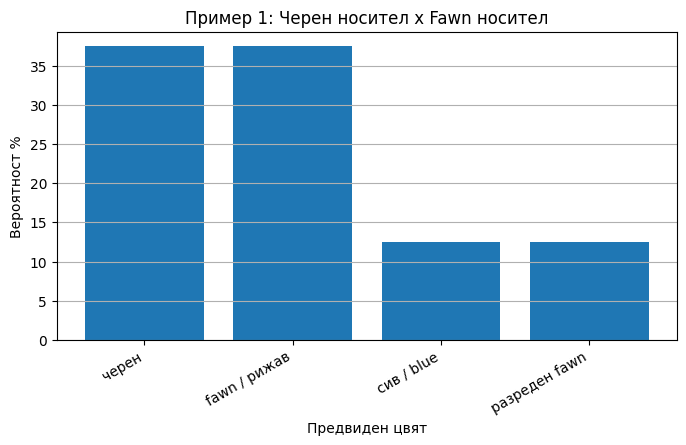

Пример 2: Чисто черен x Fawn
Баща: {'K': ['KB', 'KB'], 'D': ['D', 'D']}
Майка: {'K': ['ky', 'ky'], 'D': ['D', 'D']}



,Цвят,Вероятност %
0,черен,100.0


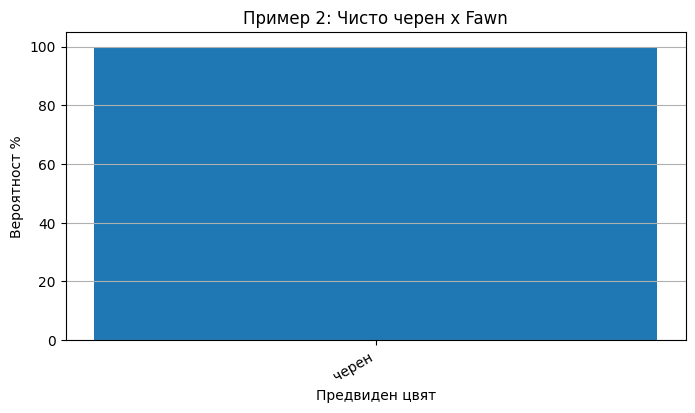

Пример 3: Тигров x Fawn
Баща: {'K': ['kbr', 'ky'], 'D': ['D', 'D']}
Майка: {'K': ['ky', 'ky'], 'D': ['D', 'D']}



,Цвят,Вероятност %
0,тигров,50.0
1,fawn / рижав,50.0


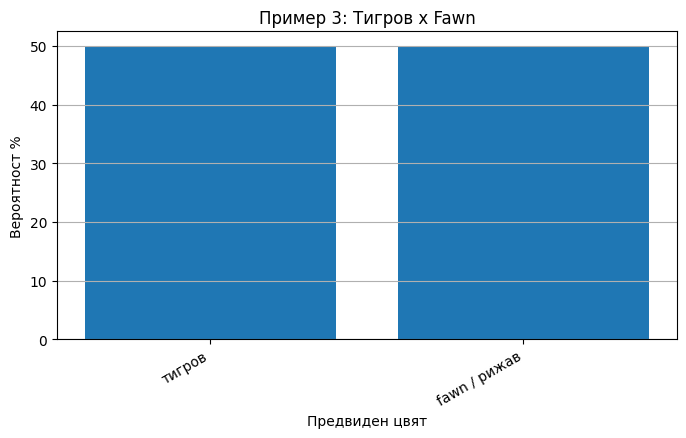

Пример 4: Черен носител x Черен носител
Баща: {'K': ['KB', 'ky'], 'D': ['D', 'd']}
Майка: {'K': ['KB', 'ky'], 'D': ['D', 'd']}



,Цвят,Вероятност %
0,черен,56.25
1,сив / blue,18.75
2,fawn / рижав,18.75
3,разреден fawn,6.25


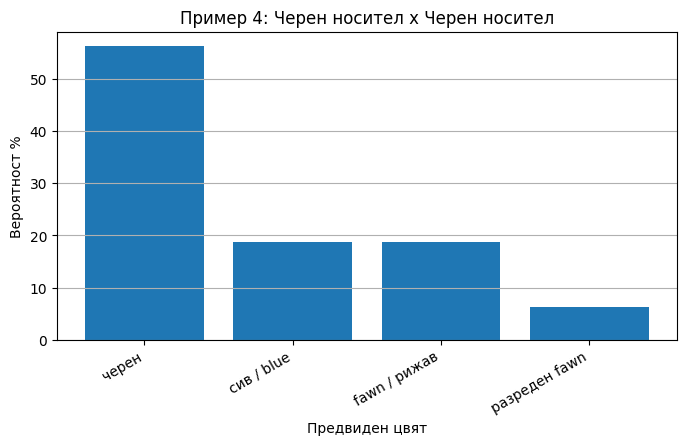

Пример 5: Тигров носител x Fawn носител
Баща: {'K': ['kbr', 'ky'], 'D': ['D', 'd']}
Майка: {'K': ['ky', 'ky'], 'D': ['D', 'd']}



,Цвят,Вероятност %
0,тигров,37.5
2,fawn / рижав,37.5
1,сиво-тигров / blue brindle,12.5
3,разреден fawn,12.5


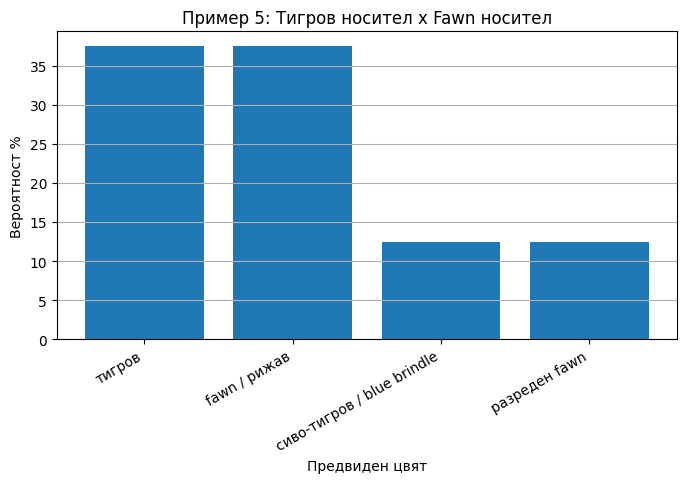

In [5]:
# ======================================================
# ПРИМЕРИ С РАЗЛИЧНИ РОДИТЕЛИ
# ======================================================

examples = [
    {
        "Име": "Пример 1: Черен носител x Fawn носител",
        "Баща": {
            "K": ["KB", "ky"],
            "D": ["D", "d"]
        },
        "Майка": {
            "K": ["ky", "ky"],
            "D": ["D", "d"]
        }
    },
    {
        "Име": "Пример 2: Чисто черен x Fawn",
        "Баща": {
            "K": ["KB", "KB"],
            "D": ["D", "D"]
        },
        "Майка": {
            "K": ["ky", "ky"],
            "D": ["D", "D"]
        }
    },
    {
        "Име": "Пример 3: Тигров x Fawn",
        "Баща": {
            "K": ["kbr", "ky"],
            "D": ["D", "D"]
        },
        "Майка": {
            "K": ["ky", "ky"],
            "D": ["D", "D"]
        }
    },
    {
        "Име": "Пример 4: Черен носител x Черен носител",
        "Баща": {
            "K": ["KB", "ky"],
            "D": ["D", "d"]
        },
        "Майка": {
            "K": ["KB", "ky"],
            "D": ["D", "d"]
        }
    },
    {
        "Име": "Пример 5: Тигров носител x Fawn носител",
        "Баща": {
            "K": ["kbr", "ky"],
            "D": ["D", "d"]
        },
        "Майка": {
            "K": ["ky", "ky"],
            "D": ["D", "d"]
        }
    }
]


def predict_color_probabilities(father, mother):
    k_probs = genotype_probabilities(father["K"], mother["K"], K_GENE_SCORE)
    d_probs = genotype_probabilities(father["D"], mother["D"], D_GENE_SCORE)

    rows = []
    color_probs = defaultdict(float)

    for k_genotype, k_probability in k_probs.items():
        for d_genotype, d_probability in d_probs.items():

            combined_probability = k_probability * d_probability

            k_score = k_numeric_score(k_genotype)
            d_score = d_numeric_score(d_genotype)

            base_color = base_color_from_k_score(k_score)
            final_color = final_color_from_scores(k_score, d_score)

            color_probs[final_color] += combined_probability

            rows.append({
                "K генотип": "/".join(k_genotype),
                "K числова сила": k_score,
                "D генотип": "/".join(d_genotype),
                "D числова сила": d_score,
                "Комбинирана вероятност %": combined_probability * 100,
                "Основен цвят": base_color,
                "Предвиден цвят": final_color
            })

    genotype_table = pd.DataFrame(rows)

    color_table = pd.DataFrame({
        "Цвят": list(color_probs.keys()),
        "Вероятност %": [value * 100 for value in color_probs.values()]
    })

    color_table = color_table.sort_values("Вероятност %", ascending=False)

    return genotype_table, color_table


for example in examples:
    print("=" * 70)
    print(example["Име"])
    print("=" * 70)

    genotype_table, color_table = predict_color_probabilities(
        example["Баща"],
        example["Майка"]
    )

    print("Баща:", example["Баща"])
    print("Майка:", example["Майка"])
    print()

    display(color_table)

    plt.figure(figsize=(8, 4))
    plt.bar(color_table["Цвят"], color_table["Вероятност %"])

    plt.title(example["Име"])
    plt.xlabel("Предвиден цвят")
    plt.ylabel("Вероятност %")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y")

    plt.show()

Черен носител × Fawn носител


,Цвят,Вероятност %
0,черен,37.5
2,fawn / рижав,37.5
1,сив / blue,12.5
3,разреден fawn,12.5


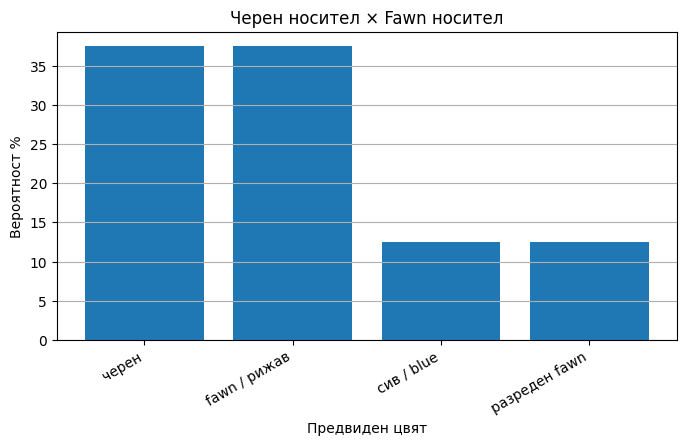

Чисто черен × Fawn


,Цвят,Вероятност %
0,черен,100.0


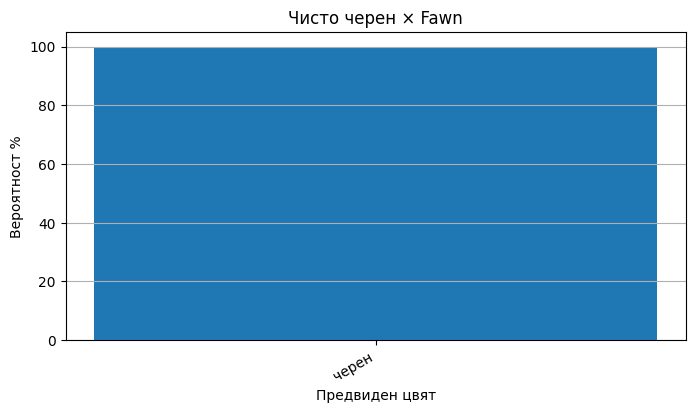

Тигров × Fawn


,Цвят,Вероятност %
0,тигров,50.0
1,fawn / рижав,50.0


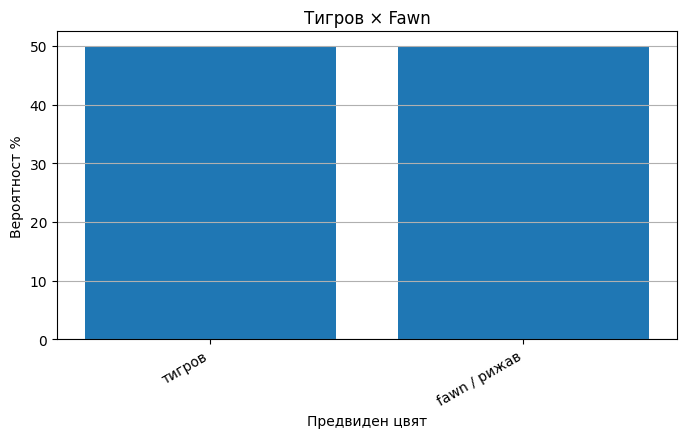

Черен носител × Черен носител


,Цвят,Вероятност %
0,черен,56.25
1,сив / blue,18.75
2,fawn / рижав,18.75
3,разреден fawn,6.25


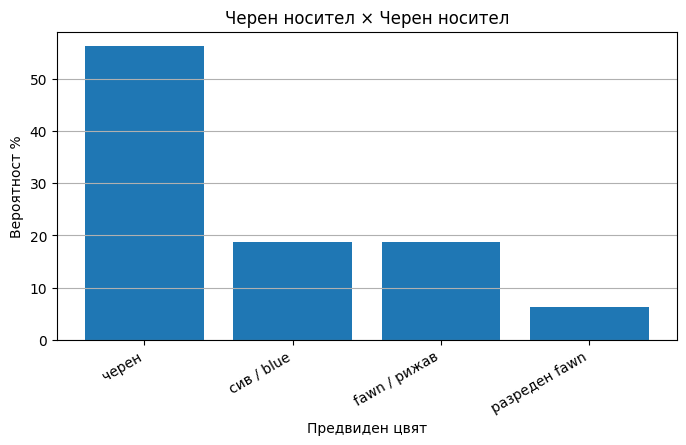

Тигров носител × Fawn носител


,Цвят,Вероятност %
0,тигров,37.5
2,fawn / рижав,37.5
1,сиво-тигров / blue brindle,12.5
3,разреден fawn,12.5


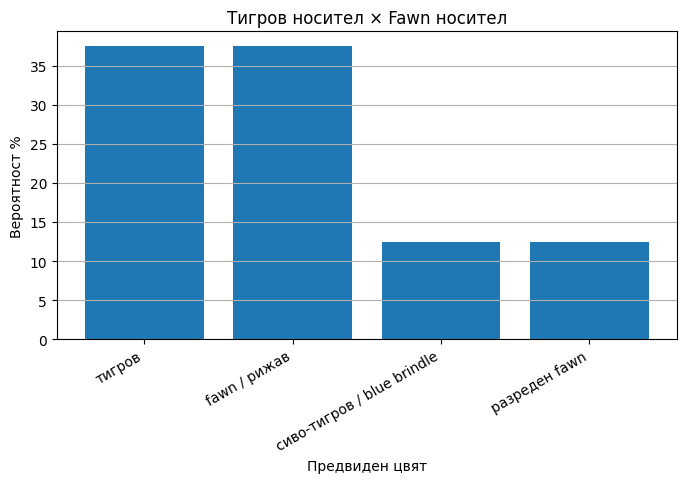

Обща таблица с всички варианти:


,Вариант,Име,Цвят,Вероятност %,Средна K сила,Средна D сила
0,1,Черен носител × Fawn носител,черен,37.50,1.50,0.5
1,1,Черен носител × Fawn носител,fawn / рижав,37.50,1.50,0.5
2,1,Черен носител × Fawn носител,сив / blue,12.50,1.50,0.5
3,1,Черен носител × Fawn носител,разреден fawn,12.50,1.50,0.5
4,2,Чисто черен × Fawn,черен,100.00,2.00,1.0
5,3,Тигров × Fawn,тигров,50.00,1.25,1.0
6,3,Тигров × Fawn,fawn / рижав,50.00,1.25,1.0
7,4,Черен носител × Черен носител,черен,56.25,2.00,0.5
8,4,Черен носител × Черен носител,сив / blue,18.75,2.00,0.5
9,4,Черен носител × Черен носител,fawn / рижав,18.75,2.00,0.5


Цвят,fawn / рижав,разреден fawn,сив / blue,сиво-тигров / blue brindle,тигров,черен
Вариант,,,,,,
1,37.50,12.50,12.50,0.0,0.0,37.50
2,0.00,0.00,0.00,0.0,0.0,100.00
3,50.00,0.00,0.00,0.0,50.0,0.00
4,18.75,6.25,18.75,0.0,0.0,56.25
5,37.50,12.50,0.00,12.5,37.5,0.00


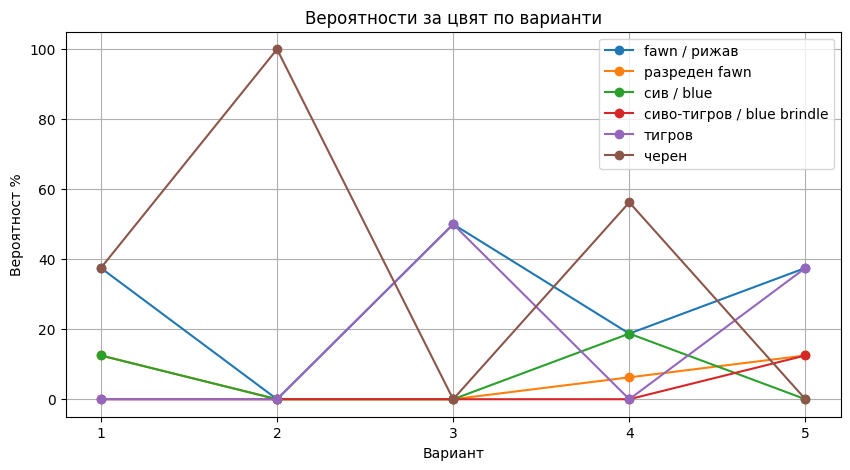

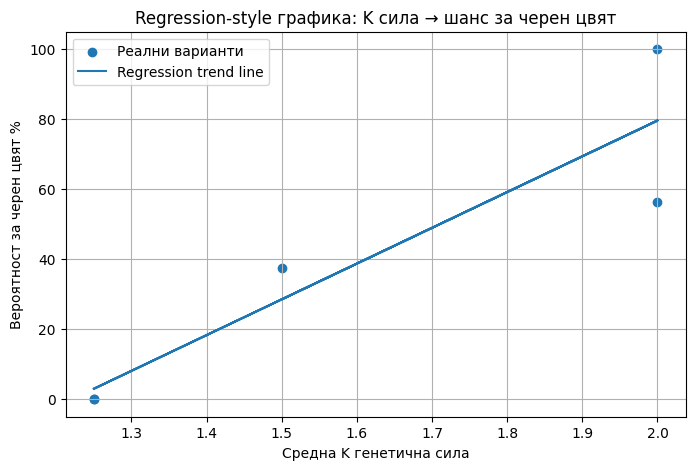

Regression-style формула:
Вероятност за черен цвят = 102.17 * K сила + -124.73
Tests passed


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ======================================================
# 1. Числова сила на гените
# ======================================================

K_GENE_SCORE = {
    "KB": 3,     # черен - най-силен
    "kbr": 2,    # тигров
    "ky": 1      # fawn / рижав
}

D_GENE_SCORE = {
    "D": 1,
    "d": 0
}

# ======================================================
# 2. Помощни функции
# ======================================================

def allele_probabilities(alleles):
    counts = Counter(alleles)
    total = len(alleles)
    return {allele: count / total for allele, count in counts.items()}


def genotype_probabilities(father_alleles, mother_alleles, score_map):
    father_probs = allele_probabilities(father_alleles)
    mother_probs = allele_probabilities(mother_alleles)

    result = defaultdict(float)

    for father_allele, father_probability in father_probs.items():
        for mother_allele, mother_probability in mother_probs.items():

            genotype = tuple(sorted(
                [father_allele, mother_allele],
                key=lambda gene: score_map[gene],
                reverse=True
            ))

            result[genotype] += father_probability * mother_probability

    return dict(result)


def k_numeric_score(k_genotype):
    return max(K_GENE_SCORE[gene] for gene in k_genotype)


def d_numeric_score(d_genotype):
    return sum(D_GENE_SCORE[gene] for gene in d_genotype)


def base_color_from_k_score(k_score):
    if k_score == 3:
        return "черен"
    elif k_score == 2:
        return "тигров"
    else:
        return "fawn / рижав"


def final_color_from_scores(k_score, d_score):
    base_color = base_color_from_k_score(k_score)

    # d_score = 0 означава d/d, тоест разреден цвят
    if d_score == 0:
        if base_color == "черен":
            return "сив / blue"
        elif base_color == "тигров":
            return "сиво-тигров / blue brindle"
        else:
            return "разреден fawn"

    return base_color


def predict_color_probabilities(father, mother):
    k_probs = genotype_probabilities(father["K"], mother["K"], K_GENE_SCORE)
    d_probs = genotype_probabilities(father["D"], mother["D"], D_GENE_SCORE)

    rows = []
    color_probs = defaultdict(float)

    for k_genotype, k_probability in k_probs.items():
        for d_genotype, d_probability in d_probs.items():

            combined_probability = k_probability * d_probability

            k_score = k_numeric_score(k_genotype)
            d_score = d_numeric_score(d_genotype)

            base_color = base_color_from_k_score(k_score)
            final_color = final_color_from_scores(k_score, d_score)

            color_probs[final_color] += combined_probability

            rows.append({
                "K генотип": "/".join(k_genotype),
                "K числова сила": k_score,
                "D генотип": "/".join(d_genotype),
                "D числова сила": d_score,
                "Комбинирана вероятност %": combined_probability * 100,
                "Основен цвят": base_color,
                "Предвиден цвят": final_color
            })

    genotype_table = pd.DataFrame(rows)

    color_table = pd.DataFrame({
        "Цвят": list(color_probs.keys()),
        "Вероятност %": [value * 100 for value in color_probs.values()]
    }).sort_values("Вероятност %", ascending=False)

    return genotype_table, color_table


def parent_k_power(parent):
    return np.mean([K_GENE_SCORE[gene] for gene in parent["K"]])


def parent_d_power(parent):
    return np.mean([D_GENE_SCORE[gene] for gene in parent["D"]])


# ======================================================
# 3. Примери с различни родители
# ======================================================

examples = [
    {
        "Вариант": 1,
        "Име": "Черен носител × Fawn носител",
        "Баща": {"K": ["KB", "ky"], "D": ["D", "d"]},
        "Майка": {"K": ["ky", "ky"], "D": ["D", "d"]}
    },
    {
        "Вариант": 2,
        "Име": "Чисто черен × Fawn",
        "Баща": {"K": ["KB", "KB"], "D": ["D", "D"]},
        "Майка": {"K": ["ky", "ky"], "D": ["D", "D"]}
    },
    {
        "Вариант": 3,
        "Име": "Тигров × Fawn",
        "Баща": {"K": ["kbr", "ky"], "D": ["D", "D"]},
        "Майка": {"K": ["ky", "ky"], "D": ["D", "D"]}
    },
    {
        "Вариант": 4,
        "Име": "Черен носител × Черен носител",
        "Баща": {"K": ["KB", "ky"], "D": ["D", "d"]},
        "Майка": {"K": ["KB", "ky"], "D": ["D", "d"]}
    },
    {
        "Вариант": 5,
        "Име": "Тигров носител × Fawn носител",
        "Баща": {"K": ["kbr", "ky"], "D": ["D", "d"]},
        "Майка": {"K": ["ky", "ky"], "D": ["D", "d"]}
    }
]

# ======================================================
# 4. Изчисляване на всички варианти
# ======================================================

all_results = []

for example in examples:
    genotype_table, color_table = predict_color_probabilities(
        example["Баща"],
        example["Майка"]
    )

    combined_k_power = (
        parent_k_power(example["Баща"]) + parent_k_power(example["Майка"])
    ) / 2

    combined_d_power = (
        parent_d_power(example["Баща"]) + parent_d_power(example["Майка"])
    ) / 2

    for _, row in color_table.iterrows():
        all_results.append({
            "Вариант": example["Вариант"],
            "Име": example["Име"],
            "Цвят": row["Цвят"],
            "Вероятност %": row["Вероятност %"],
            "Средна K сила": combined_k_power,
            "Средна D сила": combined_d_power
        })

    print("=" * 80)
    print(example["Име"])
    print("=" * 80)
    display(color_table)

    # Графика за всеки вариант
    plt.figure(figsize=(8, 4))
    plt.bar(color_table["Цвят"], color_table["Вероятност %"])

    plt.title(example["Име"])
    plt.xlabel("Предвиден цвят")
    plt.ylabel("Вероятност %")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y")
    plt.show()

results = pd.DataFrame(all_results)

# ======================================================
# 5. Обща таблица
# ======================================================

print("Обща таблица с всички варианти:")
display(results)

# ======================================================
# 6. Обща графика като regression / line chart
# ======================================================

pivot_table = results.pivot_table(
    index="Вариант",
    columns="Цвят",
    values="Вероятност %",
    fill_value=0
)

display(pivot_table)

plt.figure(figsize=(10, 5))

for color in pivot_table.columns:
    plt.plot(
        pivot_table.index,
        pivot_table[color],
        marker="o",
        label=color
    )

plt.title("Вероятности за цвят по варианти")
plt.xlabel("Вариант")
plt.ylabel("Вероятност %")
plt.xticks(pivot_table.index)
plt.grid(True)
plt.legend()
plt.show()

# ======================================================
# 7. Regression-style trend: сила на K гена → шанс за черен цвят
# ======================================================

black_rows = results[results["Цвят"] == "черен"].copy()

# Ако някой вариант няма черен цвят, добавяме 0%
all_variants = pd.DataFrame({
    "Вариант": [example["Вариант"] for example in examples],
    "Име": [example["Име"] for example in examples],
    "Средна K сила": [
        (parent_k_power(example["Баща"]) + parent_k_power(example["Майка"])) / 2
        for example in examples
    ]
})

black_probability = all_variants.merge(
    black_rows[["Вариант", "Вероятност %"]],
    on="Вариант",
    how="left"
).fillna({"Вероятност %": 0})

x = black_probability["Средна K сила"]
y = black_probability["Вероятност %"]

trend_a, trend_b = np.polyfit(x, y, 1)
trend_y = trend_a * x + trend_b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Реални варианти")
plt.plot(x, trend_y, label="Regression trend line")

plt.title("Regression-style графика: K сила → шанс за черен цвят")
plt.xlabel("Средна K генетична сила")
plt.ylabel("Вероятност за черен цвят %")
plt.grid(True)
plt.legend()
plt.show()

print("Regression-style формула:")
print(f"Вероятност за черен цвят = {trend_a:.2f} * K сила + {trend_b:.2f}")

# ======================================================
# 8. Test
# ======================================================

assert len(results) > 0
assert len(pivot_table) == len(examples)

print("Tests passed")

# Обобщение — какво направих

В този notebook направих тестова проба за **Cane Corso Color Prediction** чрез числов генетичен модел.

Идеята ми беше да проверя как мога математически да изчисля вероятности за възможни цветове при малките според гените на бащата и майката.

---

## 1. Направих числов модел за гените

Дадох числова сила на K locus гените:

- `KB = 3` → черен ген, най-силен
- `kbr = 2` → тигров ген
- `ky = 1` → fawn / рижав ген

Така приех логиката:

`KB > kbr > ky`

Тоест ако в комбинацията има `KB`, основният цвят става черен.

---

## 2. Добавих D locus

След това добавих D locus, който показва дали цветът остава нормален или се разрежда:

- `D/D` → нормален цвят
- `D/d` → нормален цвят, но носи dilute ген
- `d/d` → разреден цвят

Пример:

- черен + `d/d` = сив / blue
- тигров + `d/d` = сиво-тигров / blue brindle
- fawn + `d/d` = разреден fawn

---

## 3. Създадох различни родителски варианти

Направих няколко примерни комбинации:

1. Черен носител × Fawn носител
2. Чисто черен × Fawn
3. Тигров × Fawn
4. Черен носител × Черен носител
5. Тигров носител × Fawn носител

За всеки вариант Python изчисли възможните генетични комбинации и вероятностите за цвят.

---

## 4. Изчислих вероятности

Моделът не връща само един цвят.

Той връща вероятностно разпределение, например:

- черен — определен процент
- сив / blue — определен процент
- тигров — определен процент
- fawn / рижав — определен процент

Това е по-правилно, защото при наследяване на цвят има вероятности, а не една сигурна стойност.

---

## 5. Направих графики

За всеки родителски вариант направих отделна графика.

Графиката показва какъв е шансът за всеки възможен цвят.

След това направих и обща графика, която сравнява всички варианти един срещу друг.

---

## 6. Направих regression-style графика

Добавих и графика в стил регресия:

`Средна K генетична сила → Вероятност за черен цвят`

Тази графика показва как шансът за черен цвят се променя според силата на K гените при родителите.

Важно: това не е класическа линейна регресия върху реални биологични данни, а учебна regression-style визуализация върху числов модел.

---

## 7. Добавих test

Накрая добавих basic test, който проверява дали:

- резултатите са създадени
- всички варианти са обработени
- таблиците и графиките имат данни

Това показва, че кодът работи логически правилно.

---

## Важно уточнение

Този notebook е учебна математическа симулация.

Той не е официален DNA тест и не може да гарантира реалния цвят на малките.

Причината е, че видимият цвят на кучето не винаги показва всички скрити гени, които то носи.

За реална точност е нужен DNA тест.

---

## Финален извод

В този notebook сведох цвета до числов генетичен модел:

`гени на родители → числова сила → възможни комбинации → вероятности → графики`

Така показах как може математически да се симулира вероятност за цвят при Cane Corso малки.

Това може да бъде основа за бъдещ модул:

**Cane Corso Color Genetics Simulator**